<a href="https://colab.research.google.com/github/Harshiit17/ML/blob/main/ml_toy_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [5]:
df.shape

(100, 4)

In [6]:
df = df.iloc[:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [8]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection

In [9]:
import matplotlib.pyplot as plt


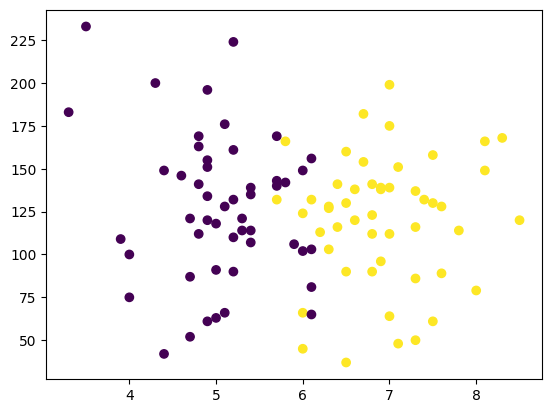

In [10]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [11]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [12]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [13]:
y.shape

(100,)

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [15]:
X_train

,cgpa,iq
7,5.0,63.0
6,5.7,143.0
19,5.2,132.0
69,8.5,120.0
82,6.5,37.0
...,...,...
12,5.4,139.0
90,7.3,86.0
75,4.8,169.0
70,6.3,127.0


In [16]:
y_train

,placement
7,0
6,0
19,0
69,1
82,1
...,...
12,0
90,1
75,0
70,1


In [17]:
X_test

,cgpa,iq
63,6.3,128.0
31,3.9,109.0
18,4.0,100.0
4,5.8,142.0
81,5.4,107.0
17,3.3,183.0
30,7.6,128.0
33,6.0,149.0
66,6.9,96.0
92,5.2,110.0


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
X_train = scaler.fit_transform(X_train)

In [21]:
X_train

array([[-0.95593141, -1.47257905],
       [-0.31998971,  0.47785678],
       [-0.77423378,  0.20967185],
       [ 2.22377708, -0.08289352],
       [ 0.4068008 , -2.1064707 ],
       [ 0.4068008 ,  0.89232439],
       [ 1.13359131, -0.18041531],
       [-1.50102429,  0.62413947],
       [ 2.04207945,  1.08736798],
       [ 0.86104487, -1.44819861],
       [ 1.76953301, -1.08249189],
       [ 0.4068008 , -0.81430696],
       [-1.13762904,  0.42909588],
       [ 0.58849843,  1.42869425],
       [ 0.95189368, -1.83828577],
       [ 0.49764961, -0.08289352],
       [-1.31932666,  0.55099812],
       [-0.59253615,  0.2828132 ],
       [ 0.31595199,  0.42909588],
       [-0.86508259,  0.11215006],
       [-1.13762904, -0.27793711],
       [ 0.04340554, -1.42381816],
       [ 1.86038182,  1.03860708],
       [ 0.86104487,  1.84316186],
       [ 0.49764961,  0.35595454],
       [ 1.13359131,  0.33157409],
       [-0.77423378, -0.81430696],
       [ 0.86104487,  1.25803111],
       [-0.86508259,

In [22]:
X_test = scaler.transform(X_test)

In [23]:
X_test

array([[ 0.22510317,  0.11215006],
       [-1.95526836, -0.35107845],
       [-1.86441955, -0.57050248],
       [-0.2291409 ,  0.45347633],
       [-0.59253615, -0.39983935],
       [-2.50036124,  1.4530747 ],
       [ 1.40613775,  0.11215006],
       [-0.04744327,  0.62413947],
       [ 0.77019606, -0.66802427],
       [-0.77423378, -0.326698  ]])

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
clf = LogisticRegression()

In [26]:
# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [27]:
y_pred = clf.predict(X_test)

In [28]:
y_test

,placement
63,1
31,0
18,0
4,0
81,0
17,0
30,1
33,0
66,1
92,0


In [29]:
from sklearn.metrics import accuracy_score

In [30]:
accuracy_score(y_test,y_pred)

0.9

In [31]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

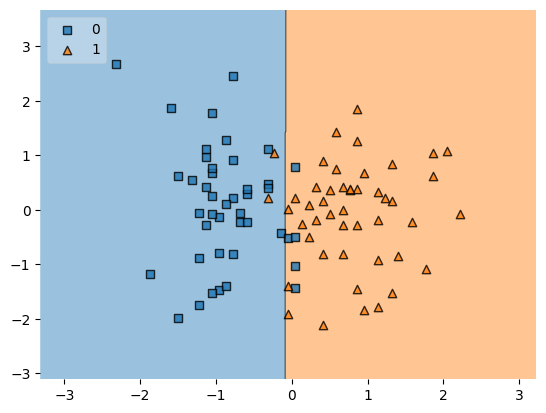

In [32]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)